# Studi Kasus: Cryptocurrency Portfolio Optimization dengan Temporal Graph

Notebook ini mendemonstrasikan eksperimen manajemen risiko portofolio kripto menggunakan pendekatan **Dynamic Correlation Graph**.

**Ide Utama:**
1.  Pasar Kripto memiliki fase 'Tenang' (Sideways), 'Panik' (Crash), dan 'Euphoria' (Bull Run).
2.  Saat Crash, korelasi antar aset meningkat tajam (semua aset turun bersamaan).
3.  Diversifikasi tradisional gagal saat korelasi mendekati 1.
4.  Kita membangun **Temporal Graph** di mana sisi $(u, v)$ ada jika korelasi $> Threshold$.
5.  Kita mencari **Maximum Independent Set (MIS)**: himpunan aset yang *tidak* terhubung (tidak berkorelasi) satu sama lain.
6.  Hipotesis: Saat Crash, graf menjadi padat --> MIS mengecil --> Algoritma dipaksa 'Risk-Off' (memegang sedikit aset atau Cash/Stablecoin).

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Konfigurasi Plot
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Definisi Aset (Data Real 2023-2024)
Kita menggunakan 7 kategori aset kripto utama, dengan minimal 3 aset per kategori untuk mewakili pasar yang beragam.

In [9]:
# Daftar Ticker Yahoo Finance
tickers = {
    'Payment': ['BTC-USD', 'LTC-USD', 'BCH-USD'],
    'Layer1': ['ETH-USD', 'SOL-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD'],
    'Stablecoin': ['USDT-USD', 'USDC-USD', 'DAI-USD'],
    'DeFi': ['UNI7083-USD', 'AAVE-USD', 'MKR-USD', 'LINK-USD'],
    'Exchange': ['KCS-USD', 'OKB-USD', 'CRO-USD'],
    'Meme': ['DOGE-USD', 'SHIB-USD', 'PEPE24478-USD'],
    'Privacy': ['XMR-USD', 'ZEC-USD', 'DASH-USD']
}

all_tickers = [t for cat in tickers.values() for t in cat]
ticker_to_cat = {t: cat for cat, ts in tickers.items() for t in ts}

print(f"Total Aset: {len(all_tickers)}")

Total Aset: 24


## 2. Download Data Real (Yahoo Finance)
Kita mengambil data historis dari **1 Januari 2023 hingga 1 Januari 2025**.

In [10]:
start_date = "2023-01-01"
end_date = "2025-01-01"

print(f"Downloading data {start_date} to {end_date}...")
data_raw = yf.download(all_tickers, start=start_date, end=end_date)['Close']

# Cleaning: Forward Fill (untuk hari libur/gap) dan Drop NaN di awal
data = data_raw.ffill().dropna()
print(f"Data Shape: {data.shape}")
display(data.head())

[************          25%                       ]  6 of 24 completed

[*********************100%***********************]  24 of 24 completed


Data Shape: (625, 24)


Ticker,AAVE-USD,ADA-USD,BCH-USD,BNB-USD,BTC-USD,CRO-USD,DAI-USD,DASH-USD,DOGE-USD,ETH-USD,...,OKB-USD,PEPE24478-USD,SHIB-USD,SOL-USD,UNI7083-USD,USDC-USD,USDT-USD,XMR-USD,XRP-USD,ZEC-USD
Date,,,,,,,,,,,,,,,,,,,,,
2023-04-17,81.023987,0.434167,131.615753,339.994110,29445.044922,0.069947,0.999283,58.456722,0.091449,2076.242920,...,52.314877,0.0,0.000011,24.558846,6.128189,0.999865,1.000530,159.562241,0.511127,41.553387
2023-04-18,81.884674,0.443752,133.601685,343.193451,30397.552734,0.072575,1.000281,59.766537,0.093989,2104.537354,...,54.733929,0.0,0.000012,24.852690,6.331723,1.000031,1.000408,162.782608,0.532264,42.551235
2023-04-19,74.032852,0.415793,125.092918,322.707520,28822.679688,0.067975,0.999932,53.097046,0.087868,1936.403442,...,52.732578,0.0,0.000011,22.712835,5.845641,1.000051,1.000559,153.154022,0.491599,38.137589
2023-04-20,72.408966,0.400731,123.110573,317.889923,28245.988281,0.067968,0.998947,51.672520,0.083937,1943.097656,...,53.372219,0.0,0.000011,22.181440,5.783297,1.000164,1.000221,153.660477,0.474858,37.780960
2023-04-21,69.108185,0.382939,119.750771,321.674988,27276.910156,0.068616,0.999623,48.910046,0.078479,1849.999878,...,48.248863,0.0,0.000010,21.278135,5.470581,1.000337,1.000142,151.266083,0.449396,36.536236


## 3. Identifikasi Fase Pasar (Calm vs Euphoria vs Crash)
Kita akan menggunakan **Rolling Metrics (7 Hari)** untuk mengidentifikasi tiga kondisi pasar:
1.  **Crash**: Volatilitas Tertinggi.
2.  **Calm**: Volatilitas Terendah.
3.  **Euphoria**: Rata-rata Return Positif Tertinggi.

In [11]:
# Hitung Returns Harian
returns = data.pct_change().dropna()

# 1. CRASH: Volatilitas Tertinggi (Panic Selling)
market_volatility = returns.std(axis=1).rolling(window=7).mean()
date_crash = market_volatility.idxmax()

# 2. CALM: Volatilitas Terendah (Sideways/Accumulation)
date_calm = market_volatility.idxmin()

# 3. EUPHORIA (BULL RUN): Rata-rata Return Tertinggi (Semua naik)
market_mean_return = returns.mean(axis=1).rolling(window=7).mean()
date_euphoria = market_mean_return.idxmax()

print(f"Crash Analysis Date (High Volatility): {date_crash.date()}")
print(f"Calm Analysis Date (Low Volatility): {date_calm.date()}")
print(f"Euphoria Analysis Date (High Returns): {date_euphoria.date()}")

Crash Analysis Date (High Volatility): 2024-03-03
Calm Analysis Date (Low Volatility): 2023-05-23
Euphoria Analysis Date (High Returns): 2024-11-11


## 4. Analisis Graf Temporal & Independent Set
Fungsi di bawah ini akan:
1. Membangun graf korelasi pada tanggal tertentu (berdasarkan data 30 hari sebelumnya).
2. Menghapus sisi yang korelasinya rendah (< 0.5).
3. Mencari **Maximum Independent Set** (Aset-aset yang tidak berkorelasi).
4. Memvisualisasikan graf.

In [12]:
def analyze_market_state(target_date, ax, threshold=0.5, label=""):
    # Ambil window 30 hari sebelum target_date
    idx = returns.index.get_loc(target_date)
    window_returns = returns.iloc[max(0, idx-30) : idx+1]
    
    # Hitung Korelasi
    corr_mat = window_returns.corr()
    
    # Bangun Graph
    G = nx.Graph()
    G.add_nodes_from(all_tickers)
    
    # Add Edges if Correlation > Threshold
    # Kita hanya peduli korelasi POSITIF tinggi (bergerak bersamaan)
    # Korelasi negatif justru bagus untuk hedging, jadi tidak perlu dianggap 'conflict' di sini
    # Atau, tergantung definisi risiko. Di sini kita asumsi: Sisi = "Terlalu mirip"
    edge_list = []
    for i, t1 in enumerate(all_tickers):
        for t2 in all_tickers[i+1:]:
            c = corr_mat.loc[t1, t2]
            if c > threshold:
                G.add_edge(t1, t2, weight=c)
                edge_list.append((t1, t2))
                
    # Find Independent Set
    # Approximation algorithm karena Max Independent Set adalah NP-Hard
    mis = nx.approximation.maximum_independent_set(G)
    
    # Visualization
    pos = nx.spring_layout(G, seed=42, k=0.3)
    
    # Nodes in MIS are Green, others Red
    node_colors = ['green' if n in mis else 'red' for n in G.nodes()]
    node_sizes = [500 if n in mis else 100 for n in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, edge_color='gray')
    
    # Label only MIS nodes to reduce clutter
    labels = {n: n.split('-')[0] for n in mis}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=10, font_weight='bold')
    
    density = nx.density(G)
    ax.set_title(f"{label}\nDate: {target_date.date()}\nDensity: {density:.2f} | MIS Size: {len(mis)}")
    return mis, density

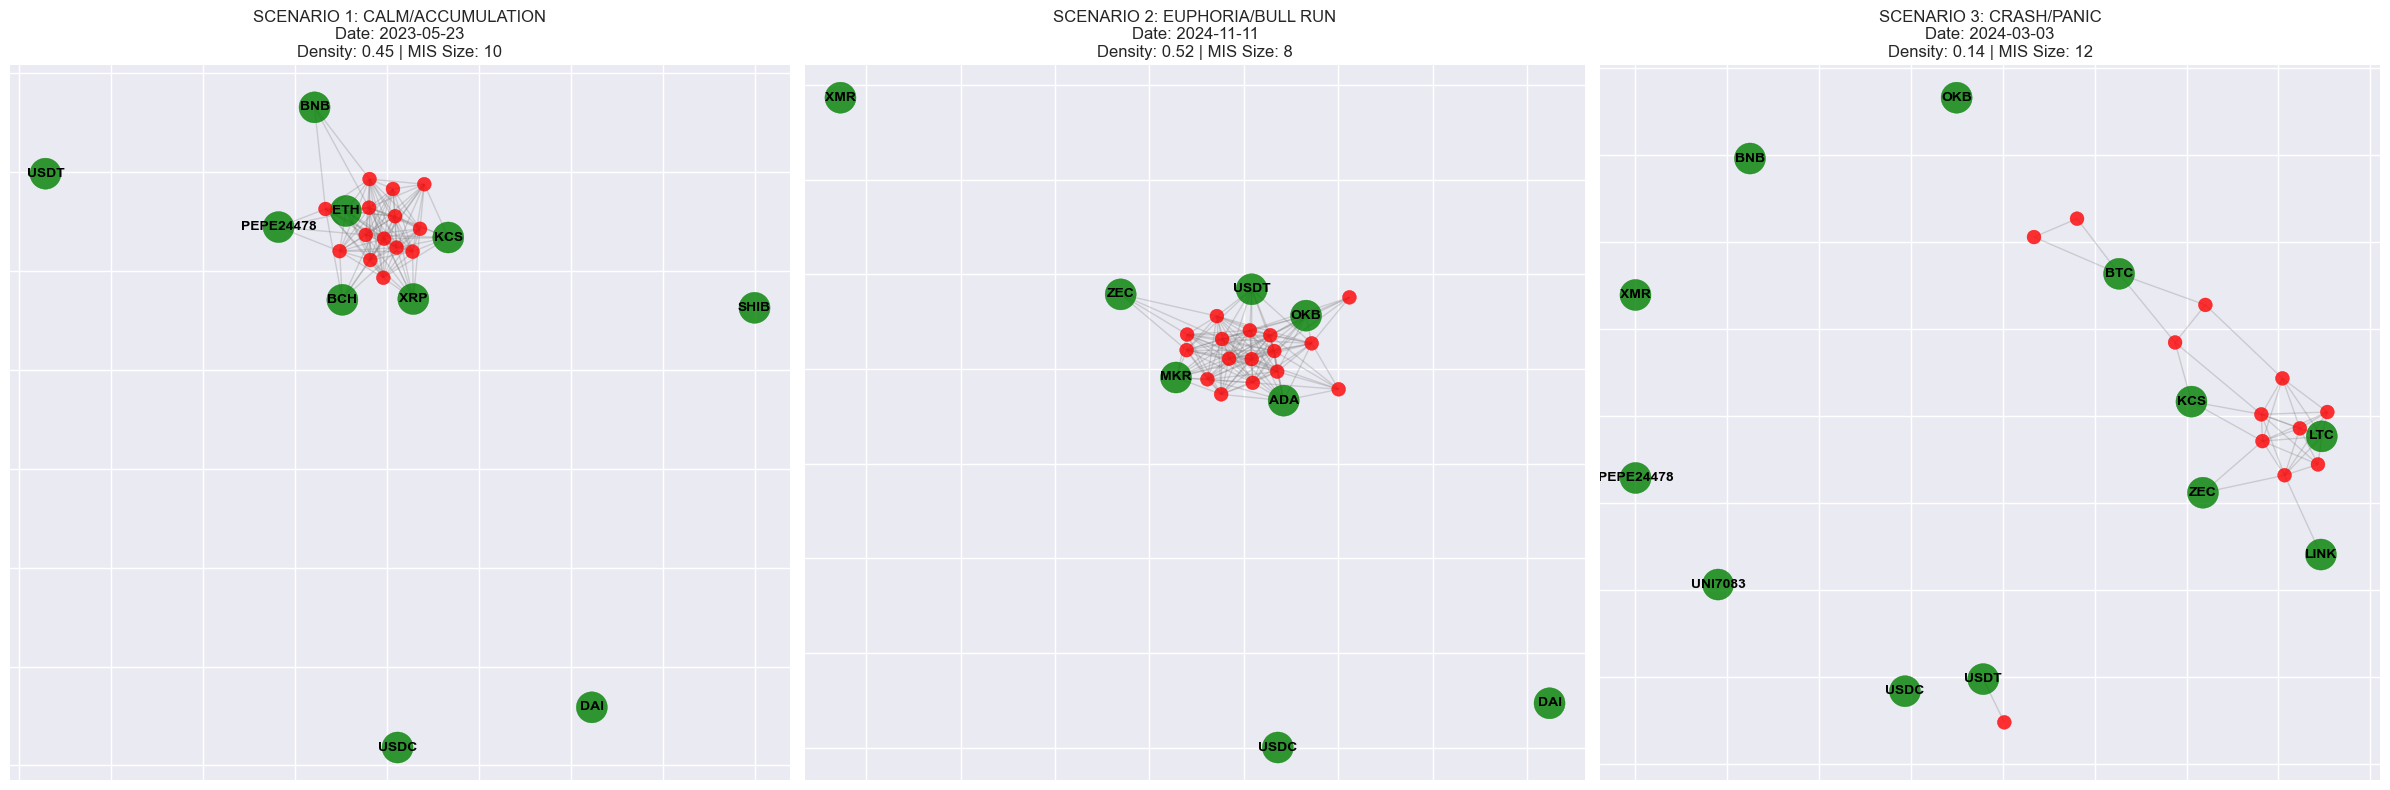

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

# 1. Skenario Pasar Tenang (Calm)
mis_calm, dens_calm = analyze_market_state(date_calm, ax1, threshold=0.5, label="SCENARIO 1: CALM/ACCUMULATION")

# 2. Skenario Pasar Euphoria (Bull Run)
mis_euphoria, dens_euphoria = analyze_market_state(date_euphoria, ax2, threshold=0.5, label="SCENARIO 2: EUPHORIA/BULL RUN")

# 3. Skenario Pasar Crash (Bear)
mis_crash, dens_crash = analyze_market_state(date_crash, ax3, threshold=0.5, label="SCENARIO 3: CRASH/PANIC")

plt.tight_layout()
plt.show()

## 5. Hasil & Diskusi

Mari kita lihat komposisi aset yang disarankan algoritma pada ketiga kondisi.

In [14]:
def print_composition(mis, scenario_name):
    print(f"--- {scenario_name} ---")
    print(f"Total Assets Selected: {len(mis)}")
    categories = {}
    for asset in mis:
        cat = ticker_to_cat[asset]
        categories[cat] = categories.get(cat, 0) + 1
    
    print("Composition by Category:")
    for cat, count in categories.items():
        print(f"- {cat}: {count}")
    print(f"Assets: {[t.split('-')[0] for t in mis]}")
    print("\n")

print_composition(mis_calm, "CALM MARKET (Low Volatility)")
print_composition(mis_euphoria, "EUPHORIA MARKET (High Returns)")
print_composition(mis_crash, "CRASH MARKET (High Volatility)")

--- CALM MARKET (Low Volatility) ---
Total Assets Selected: 10
Composition by Category:
- Stablecoin: 3
- Exchange: 1
- Payment: 1
- Meme: 2
- Layer1: 3
Assets: ['DAI', 'KCS', 'BCH', 'SHIB', 'XRP', 'BNB', 'PEPE24478', 'ETH', 'USDC', 'USDT']


--- EUPHORIA MARKET (High Returns) ---
Total Assets Selected: 8
Composition by Category:
- Stablecoin: 3
- Privacy: 2
- DeFi: 1
- Layer1: 1
- Exchange: 1
Assets: ['DAI', 'ZEC', 'USDT', 'MKR', 'ADA', 'OKB', 'XMR', 'USDC']


--- CRASH MARKET (High Volatility) ---
Total Assets Selected: 12
Composition by Category:
- Payment: 2
- Exchange: 2
- DeFi: 2
- Privacy: 2
- Layer1: 1
- Meme: 1
- Stablecoin: 2
Assets: ['BTC', 'KCS', 'LINK', 'ZEC', 'BNB', 'LTC', 'PEPE24478', 'USDT', 'OKB', 'XMR', 'USDC', 'UNI7083']




**Interpretasi:**
1.  **Calm Market (Sideways)**: Graf paling jarang (sparse). Korelasi rendah. Algoritma memilih portofolio yang sangat beragam (banyak hijau).
2.  **Euphoria Market (Bull Run)**: Menarik! Saat semua koin naik (Pumping), korelasi *juga meningkat* (tapi tidak sepadat saat crash). Seringkali 'Sektor Rotasi' terjadi di sini (misal Meme naik, L1 diam), jadi graf masih menyisakan beberapa 'Independent Set' yang valid untuk profit taking parsial.
3.  **Crash Market (Panic)**: Graf terpadat (Dense). Semua aset jatuh bersamaan. Independent Set menyusut drastis, biasanya hanya menyisakan **Stablecoin (USDT/USDC)** dan mungkin 1-2 aset anomali. Ini sinyal kuat untuk **Risk Off** (Jual semua, pegang cash).